# Polar night events: 

In [ ]:
import glob
import xarray as xr
from sklearn.linear_model import LinearRegression
import math
import datetime 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from xarray.plot.utils import _infer_interval_breaks as infer_interval_breaks
import pandas as pd
import matplotlib.dates as dts
from matplotlib.colors import LogNorm, Normalize
from scipy.ndimage.filters import gaussian_filter
from matplotlib.dates import DateFormatter
from datetime import timedelta
import re
import os
import matplotlib
from pathlib import Path
from scipy import stats
from scipy.optimize import curve_fit
import matplotlib as mpl
from scipy.stats import percentileofscore
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

plt.rcParams["font.family"] = 'monospace'

C:\Users\Dell\AppData\Local\Temp\ipykernel_19604\3816121579.py:13: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


In [129]:
# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

In [130]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

In [4]:
path_for_events = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\event_days_nc'
files = glob.glob(path_for_events+'\\*.nc')
XR_resampled = xr.open_dataset(files[0])

In [5]:
path_for_events = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds'
files = glob.glob(path_for_events+'\\*.nc')
print(files[0])
XR_resampled = xr.open_dataset(files[0])
variables = list(XR_resampled.variables)
print(variables)

drop_columns = ['pos_ions', 'neg_particles', 'pos_particles', 'neg_ion_flags', 'pos_ion_flags', 'neg_particle_flags', 'pos_particle_flags']
XR_resampled = XR_resampled.drop_vars(drop_columns)
drop_dims = ['flag']
XR_resampled = XR_resampled.drop_vars(drop_dims)

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\nais30min_2022_04.nc
['neg_ions', 'pos_ions', 'neg_particles', 'pos_particles', 'neg_ion_flags', 'pos_ion_flags', 'neg_particle_flags', 'pos_particle_flags', 'diameter', 'time', 'flag']


# load data: 
and combine NAIS and DMPS data

In [6]:
def from_Dp2lDp(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset,
xr.DataArray]:
    """
    Convert particle diameter to log10(particle diameter)

    Parameters
    ----------
    o : xr.Dataset
        Dataset with a 'Dp' variable

    Returns
    -------
    xr.Dataset
        Dataset with a 'lDp' variable added,
        where 'lDp' is the base-10 logarithm of 'Dp'.
    """
    lDp = np.log10(o['Dp'])
    o = o.assign_coords({'lDp': lDp})
    return o

def set_lDp(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)
    if 'lDp' not in coords:
        o = from_Dp2lDp(o)
    if 'lDp' not in dims:
        o = o.swap_dims({'Dp': 'lDp'})
    return o

def dp_regrid(da, *, n_subs, log_dy):

    if isinstance(da, xr.DataArray):
        assert da.name == 'dndlDp'
        da_ = da
    elif isinstance(da, xr.Dataset):
        da_ = da['dndlDp']

    # Keep original time coordinate
    time = da_.time

    # Convert Dp -> lDp
    ds1 = set_lDp(da_).reset_coords(drop=True)

    # Fine-grid spacing
    dy = log_dy / n_subs

    # Original lDp interval boundaries
    ints = infer_interval_breaks(
        ds1['lDp'],
        check_monotonic=True
    )

    ym_ = float(ints[0])
    yM_ = float(ints[-1])

    # Align fine grid with dy
    ym = np.round(ym_ / dy) * dy
    yM = np.round(yM_ / dy) * dy

    # Fine lDp grid
    yl = np.arange(
        ym,
        yM + dy / 2,
        dy
    )

    # Interpolate
    d1 = ds1.interp(
        lDp=yl,
        kwargs=dict(fill_value="extrapolate")
    )

    # Number of complete output bins
    n_bins = len(yl) // n_subs

    # Discard incomplete final bin
    d1 = d1.isel(
        lDp=slice(0, n_bins * n_subs)
    )

    # ---------------------------------------------------------
    # Reshape:
    #
    # (time, fine_lDp)
    #
    #        ↓
    #
    # (time, lDp_bin, sub)
    # ---------------------------------------------------------

    values = d1.values.reshape(
        len(time),
        n_bins,
        n_subs
    )

    # Mean over subintervals
    values = values.mean(axis=2)

    # Output lDp coordinates
    lDp = (
        ym
        + (np.arange(n_bins) + 0.5) * log_dy
    )

    # Construct output explicitly
    dsout = xr.DataArray(
        values,
        dims=('time', 'lDp'),
        coords={
            'time': time,
            'lDp': lDp,
        },
        name='dndlDp',
        attrs=da_.attrs,
    )

    return dsout

def from_lDp2Dp(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset,
xr.DataArray]:
    """
    Convert log10(particle diameter) to particle diameter

    Parameters
    ----------
    o : xr.Dataset
        Dataset with a 'lDp' variable

    Returns
    -------
    xr.Dataset
        Dataset with a 'Dp' variable added,
        where 'Dp' is the base-10 exponential of 'lDp'.
    """
    Dp = 10 ** (o['lDp'])
    o = o.assign_coords({'Dp': Dp})
    return o


def set_sec(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)
    if 'secs' not in coords:
        o = from_time2sec(o)
    if 'secs' not in dims:
        o = o.swap_dims({'time': 'secs'})
    return o

def from_sec2time(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset, xr.DataArray]:
    """
    Convert seconds since 1970-01-01 to time

    Parameters
    ----------
    o : Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'secs' coordinate

    Returns
    -------
    Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'time' coordinate added,
        where 'time' is the date and time corresponding to the
        number of seconds since 1970-01-01.
    """
    secs = o['secs'].astype('datetime64[s]')
    o = o.assign_coords({'time': secs})
    return o

def from_time2sec(o: Union[xr.Dataset, xr.DataArray]) -> Union[xr.Dataset, xr.DataArray]:
    """
    Convert time to seconds since 1970-01-01

    Parameters
    ----------
    o : Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'time' coordinate

    Returns
    -------
    Union[xr.Dataset, xr.DataArray]
        DataArray or Dataset with a 'secs' coordinate added,
        where 'secs' is the time in seconds since 1970-01-01.
    """
    date = o['time']
    # handle numeric time coordinates (already seconds) or datetime64 with various units
    vals = date.values
    # numeric type: assume seconds since epoch already
    if np.issubdtype(vals.dtype, np.number):
        secs = vals.astype('float64')
    else:
        # try to compute seconds since UNIX epoch robustly
        try:
            epoch = np.datetime64('1970-01-01T00:00:00')
            secs = (vals - epoch) / np.timedelta64(1, 's')
        except Exception:
            # fallback: use pandas to_datetime then convert to seconds
            try:
                secs = pd.to_datetime(vals).astype('int64') / 1e9
            except Exception:
                # last resort: attempt matplotlib date2num then convert days to seconds
                try:
                    import matplotlib.dates as mdates
                    secs = (mdates.date2num(vals) - mdates.date2num(np.datetime64('1970-01-01'))) * 86400.0
                except Exception:
                    raise ValueError('Unsupported time coordinate dtype for from_time2sec: %s' % (vals.dtype,))

    # assign secs coordinate aligned with the time dimension
    o = o.assign_coords({'secs': (date.dims, secs)})
    return o

def set_time(o):
    dims = list(o.dims)
    coords = list(o.coords)
    # o_coords = set(coords)-set(dims)

    if 'time' not in coords:
        o = from_sec2time(o)

    if 'time' not in dims:
        o = o.swap_dims({'secs': 'time'})

    return o

def set_Dp(o):
    dims = list(o.dims)
    coords = list(o.coords)
    if 'Dp' not in coords:
        # print(coords)
        o = from_lDp2Dp(o)
    if 'Dp' not in dims:
        o = o.swap_dims({'lDp': 'Dp'})
    return o

def upsample_ts(o, dt):
    dt = float(dt)
    orgi_dt = set_sec(o)['secs'].diff('secs').mean().item()
    assert dt <= orgi_dt, 'you are trying to upsample when you should be downsampling'
    orig_dim = list(o.dims)
    print('original dims:', orig_dim)
    o = set_time(o)
    o = o.resample({'time': pd.Timedelta(dt, unit='s')}).interpolate('linear')
    if 'time' in orig_dim:
        o = set_time(o)
    if 'secs' in orig_dim:
        o = set_sec(o)
    return o

def rename_resample_xr(XR_resampled, polarity='neg', mode='particles', resolution='15T', 
                           average='median'):
    xr_nais = XR_resampled[str(polarity)+'_'+str(mode)].to_pandas()
    #resample to 15 minutes
    if average == 'mean':
        ds_ = xr_nais.stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':resolution}).mean()
    if average == 'median':
        ds_ = xr_nais.stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':resolution}).median()
    ds_.drop_duplicates(dim='time')
    return ds_

def regrid_ds(ds_):
    ## regridding ppsamples a time series with a given time step. Regrids the diameter distribution of 40 to 27
    ds = (ds_.pipe(dp_regrid, log_dy=.05, n_subs=10).pipe(set_Dp))    
    return ds

def interpolate_ds(ds, minutes=15):
    ds=ds.pipe(upsample_ts, dt=minutes*60) #linear interpolation
    ds = ds.to_dataset()
    return ds

In [7]:
#load DMPS data which has a resolution of 30 minutes

load_path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\dmps'
filename='DMPS_QC_2022_2024_30min.nc'
id_name='dmps'

xr_dmps_30min = xr.open_dataset(load_path+'\\'+filename)
df_dmps = xr_dmps_30min['dmps_number'].to_pandas()
diameters_m = list(df_dmps.columns)
print(diameters_m)

#rename and resample to 30 minuyes (should already be)
ds_dmps_ = df_dmps[diameters_m].stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':'30min'}).median()
#regrid 
ds_dmps = (ds_dmps_.pipe(dp_regrid, log_dy=.05, n_subs=10).pipe(set_Dp))

#seconds 15 minutes multipled by 60seconds = 900 seconds
ds_dmps=ds_dmps.pipe(upsample_ts, dt=15*60) 

ds_dmps = ds_dmps.to_dataset()
ds_dmps = ds_dmps.expand_dims({'id':['dmps']})
ds_dmps = ds_dmps.drop_vars('lDp')

print(ds_dmps.dims)
print(ds_dmps.Dp)

########### LOAD 5 MINUTE NAIS DATA ####################################################################
resolution = '5min'
path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\resampled\resampled_removed_snow_clouds_bad_charged'
XR_resampled = xr.open_dataset(path+'\\'+str(resolution)+'_removed_snow_clouds_bad_charged.nc')
polarity='neg';
mode='particles'

########## REGRID AND INTERPOLATE 5 MINUTE NAIS DATA TO 15 MINUTES ####################################################################
ds_nais = rename_resample_xr(XR_resampled, polarity='neg', mode='particles', 
                             resolution='15min', average='median')

ds_nais = regrid_ds(ds_nais)
ds_nais =  interpolate_ds(ds_nais, minutes=15)

ds_nais = ds_nais.expand_dims(id=["nais"])
ds_nais = ds_nais.drop_vars('lDp')
print(ds_nais.dims)
print(ds_nais.Dp)

[5.012e-09, 5.623000000000001e-09, 6.31e-09, 7.079e-09, 7.943e-09, 8.913e-09, 1e-08, 1.122e-08, 1.2589000000000001e-08, 1.4125e-08, 1.5849000000000002e-08, 1.7783e-08, 1.9953e-08, 2.2387e-08, 2.5119e-08, 2.8184000000000003e-08, 3.1623000000000005e-08, 3.5481000000000005e-08, 3.9811000000000005e-08, 4.4668e-08, 5.0119e-08, 5.6234000000000006e-08, 6.3096e-08, 7.0795e-08, 7.943300000000001e-08, 8.9125e-08, 1.0000000000000001e-07, 1.12202e-07, 1.25893e-07, 1.41254e-07, 1.58489e-07, 1.7782800000000002e-07, 1.9952600000000004e-07, 2.2387200000000003e-07, 2.51189e-07, 2.8183800000000004e-07, 3.16228e-07, 3.54813e-07, 3.9810700000000003e-07, 4.4668400000000003e-07, 5.01187e-07, 5.623410000000001e-07, 6.309570000000001e-07, 7.07946e-07]
original dims: ['time', 'Dp']
FrozenMappingWarningOnValuesAccess({'id': 1, 'Dp': 44, 'time': 131243})
<xarray.DataArray 'Dp' (Dp: 44)> Size: 352B
array([5.011872e-09, 5.623413e-09, 6.309573e-09, 7.079458e-09, 7.943282e-09,
       8.912509e-09, 1.000000e-08, 1.12

In [8]:
def clean_dp(ds):
    log_dp = np.log10(ds.Dp.values)
    # Round log10(Dp) to remove floating-point noise
    log_dp = np.round(log_dp, 10)
    return ds.assign_coords(Dp=10 ** log_dp)

ds_nais = clean_dp(ds_nais)
ds_dmps = clean_dp(ds_dmps)

In [9]:
ds_concat_nais_dmps = xr.concat(
    [
        ds_nais,
        ds_dmps
    ],
    dim="id", join="outer"
)

In [10]:
ds_concat_nais_dmps

<xarray.Dataset> Size: 136MB
Dimensions:  (id: 2, time: 131809, Dp: 64)
Coordinates:
  * id       (id) object 16B 'nais' 'dmps'
  * time     (time) datetime64[ns] 1MB 2021-01-01 ... 2024-10-05
  * Dp       (Dp) float64 512B 5.012e-10 5.623e-10 ... 6.31e-07 7.079e-07
Data variables:
    dndlDp   (id, time, Dp) float64 135MB nan nan nan nan ... nan nan nan nan

In [11]:
def get_nais_dmps(d, slice_diameter=3.9e-08):
    d1 = d[['dndlDp']].loc[{'id':'nais','Dp':slice(0,slice_diameter)}]
    d2 = d[['dndlDp']].loc[{'id':'dmps','Dp':slice(slice_diameter+.00001e-8,1)}]*2
    dc = xr.concat([d1, d2], dim='Dp')
    dc['id'] = 'nd'
    dcc = xr.concat([d,dc],dim='id')
    return dcc

ds_nais_dmps = ds_concat_nais_dmps.pipe(get_nais_dmps, slice_diameter=3.9e-08)
ds_nais_dmps = ds_nais_dmps.loc[{'time':slice('2022-04-17','2024-10-04')}]

C:\Users\Dell\AppData\Local\Temp\ipykernel_19604\1213337103.py:4: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  dc = xr.concat([d1, d2], dim='Dp')


In [12]:
# #load the quality checked DMPS data
# load_path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\dmps'
# filename='DMPS_QC_2022_2024_30min.nc'
# xr_dmps_30T = xr.open_dataset(load_path+'\\'+filename)

# df_dmps = xr_dmps_30T['dmps_number'].to_pandas()
# diameters_m = list(df_dmps.columns)
# print(diameters_m)

# ds_dmps_ = df_dmps[diameters_m].stack().to_xarray().rename({'diameter':'Dp'}).assign_coords({'Dp':lambda d:d['Dp'].astype(float)}).rename('dndlDp').sortby('time').resample({'time':'30T'}).median()
# ds_dmps = (ds_dmps_.pipe(bu.dp_regrid,log_dy=.05,n_subs=10).pipe(bu.set_Dp).pipe(bu.upsample_ts,15*60))

# ds_dmps = (ds_dmps.pipe(bu.dp_regrid,log_dy=.05,n_subs=10)
#     .pipe(bu.set_Dp)
#     .pipe(bu.upsample_ts,15*60))
# ds_dmps = ds_dmps.to_dataset()
# ds_dmps = ds_dmps.expand_dims({'id':['dmps']})
# ds_dmps = ds_dmps.drop('lDp')

# resolution = '5T'
# path = r'C:/Users/DominicHeslinRees/NAIS_work/ZEP_processed_files/resampled_removed_snow_clouds_bad_charged/'
# XR_resampled = xr.open_dataset(path+'\\'+str(resolution)+'_removed_snow_clouds_bad_charged.nc')

# polarity='neg';
# mode='particles'

# ########BOUNDARIES PUT IN ########################
# # use_positive = ['2023-10-26', '2024-04-24', '2024-05-06', '2024-05-20']
# # if date in use_positive:
# #     print("use positive")
# #     var = 'pos_particles'
# # else: 
# #     var = 'neg_particles'

# ds_nais = regrid_resample_addid_save_file(XR_resampled, current_dir=current_dir, polarity=polarity, 
#                                mode=mode, resample = '15T', average = 'median')
# ds_nais = ds_nais.drop('lDp')
# ds_nais_dmps = (xr.concat([ds_nais,ds_dmps], dim='id'))

# ds_nais_dmps = ds_nais_dmps.loc[{'time':slice('2022-04-17','2024-10-04')}]
# ds_nais_dmps = ds_nais_dmps.pipe(get_nais_dmps, slice_diameter=3.9e-08)

In [13]:
ds_nais_dmps_combinnned = ds_nais_dmps.loc[{'id':'nd'}]
ds_nais_dmps_combinnned = ds_nais_dmps_combinnned.drop_vars(['id'])
ds_nais_dmps_combinnned = ds_nais_dmps_combinnned.rename({'Dp': 'diameter'})
#ds_nais_dmps_combinnned.to_netcdf(r'C:\Users\DominicHeslinRees\NAIS_work\select_bonds\tests\test_nais_dmps_diameter.nc')

In [14]:
def slice_by_time(ds, start_time, end_time):
    ds = ds.sel(time=slice(start_time, end_time))
    return ds

In [15]:
path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\event_times'
filename='events_start_and_end_times_checked.xlsx' 

df_NPF_plusgrowth = pd.read_excel(path+'\\'+filename, index_col=0, parse_dates=True)
df_NPF_plusgrowth.index.name = 'event'

df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_event'].dt.date
df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_date'].astype(str)
df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_event'].dt.date
df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_date'].astype(str)

date='2022-04-18'
df_NPF_plusgrowth[df_NPF_plusgrowth['start_date'] == str(date)]

date='2022-04-23'
df_NPF_plusgrowth[df_NPF_plusgrowth['start_date'] == str(date)]

,start_event,end_event,event_class,comments,start_date,end_date
event,,,,,,
2022-04-23,2022-04-23 06:00:00,2022-04-23 21:00:00,Class II,NaN,2022-04-23,2022-04-23


## slice events: 

In [18]:
polar_night_dates = ['2022-11-25','2023-10-25', '2023-10-28',
                     '2023-11-01', '2023-11-02']

# event1 = 2022-11-25 20:00 - 2022-11-26 15:00
# event2 = 2023-10-25 20:00 - 2023-10-26 23:50, 
# event_3a = 2023-10-28 01:00 – 2023-10-29 02:00,
# event_3b = 2023-10-28 12:00 – 2023-10-29 15:00  
# event4 2023-11-01 09:00 - 2023-11-02 18:00
# event5 2023-11-02 21:00 -2023-11-03 06:00. 

event1_starttime = pd.to_datetime('2022-11-25 20:00') 
event2_starttime = pd.to_datetime('2023-10-25 20:00')
event3a_starttime = pd.to_datetime('2023-10-28 01:00')
event3b_starttime = pd.to_datetime('2023-10-28 12:00')
event4_starttime = pd.to_datetime('2023-11-01 09:00')
event5_starttime = pd.to_datetime('2023-11-02 21:00')

event1_endtime = pd.to_datetime('2022-11-26 15:00')
event2_endtime = pd.to_datetime('2023-10-26 23:50') 
event3a_endtime = pd.to_datetime('2023-10-29 02:00')
event3b_endtime = pd.to_datetime('2023-10-29 15:00')  
event4_endtime = pd.to_datetime('2023-11-02 18:00')
event5_endtime = pd.to_datetime('2023-11-03 06:00')

event_start_times = [event1_starttime, event2_starttime, event3a_starttime, event3b_starttime, event4_starttime, event5_starttime]
event_end_times = [event1_endtime, event2_endtime, event3a_endtime, event3b_endtime, event4_endtime, event5_endtime]

In [32]:
save_events = True
savepath = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS_polarnight\events'

if save_events == True:
    for start_time, end_time in zip(event_start_times, event_end_times):  
        ds_event = slice_by_time(ds_nais_dmps_combinnned, start_time, end_time)
        datename = str(pd.to_datetime(start_time).date()).replace('-','')
        timename = str(pd.to_datetime(start_time).time()).replace(':','')[:2]
        name=datename+timename
        print(name)
        print(savepath+'\\'+str(name)+'.nc')
        ds_event.to_netcdf(savepath+'\\'+str(name)+'.nc')

2022112520
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS_polarnight\events\2022112520.nc
2023102520
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS_polarnight\events\2023102520.nc
2023102801
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS_polarnight\events\2023102801.nc
2023102812
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS_polarnight\events\2023102812.nc
2023110109
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS_polarnight\events\2023110109.nc
2023110221
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS_polarnight\events\2023110221.nc


In [110]:
def remove_bad_data(ds, bad_data, select_time=False, select_time_and_diameter=True):

    time_left = bad_data.neg_ion_time_left.values
    time_right = bad_data.neg_ion_time_right.values
    diam_left = bad_data.neg_ion_diam_left.values
    diam_right = bad_data.neg_ion_diam_right.values

    roi_ids = bad_data.neg_ion_roi_id.values

    ds_checked = ds.copy(deep=True)

    # Convert xarray datetime64 → Matplotlib date numbers
    time_num = dts.date2num(ds_checked.time.values)
    diameter = ds_checked.diameter.values

    for i in roi_ids:

        print(f"Processing ROI {i}")

        time_mask = (
            (time_num >= time_left[i]) &
            (time_num <= time_right[i])
        )

        if select_time:
            ds_checked["dndlDp"].loc[{
                "time": time_mask
            }] = np.nan

        if select_time_and_diameter:

            diameter_mask = (
                (diameter >= diam_left[i]) &
                (diameter <= diam_right[i])
            )

            mask = time_mask[:, None] & diameter_mask[None, :]

            ds_checked["dndlDp"] = ds_checked["dndlDp"].where(~mask)

    return ds_checked

# def clean_with_bounds(xr_event, date, infile_bounds):
#     #search for bounds file based on the date of the event
#     search_for_bounds = glob.glob(infile_bounds+'\\bounds\\*'+str(date).replace('-','')+'.nc')
#     print(infile_bounds+'\\bounds\\*'+str(date).replace('-','')+'.nc')
        
#     if search_for_bounds:
#         print("found bounds")
#         print(search_for_bounds[0])
#         search_for_bounds = xr.open_dataset(search_for_bounds[0])

#         xr_event_removed = remove_bad_data(xr_event, search_for_bounds, select_time=False, select_time_and_diameter=True)

#         del xr_event
#     if not search_for_bounds:
#         xr_event_removed = xr_event.copy()   
#         del xr_event
#     return xr_event_removed

In [121]:
# def remove_bad_data(ds, bad_data, select_time=False, select_time_and_diameter=True):
#     """
#     Set bad data to NaNs

#     Parameters
#     ----------
#     ds : xarray.Dataset
#         NAIS datafile
#     bad_data : xarray.Dataset
#         user-determined bad data boundaries using the `NaisChecker()`

#     Returns
#     -------
#     xarray.Dataset
#         Dataset with possible bad data set to `NaN`
#     """

#     neg_ion_bounds = [
#         bad_data.neg_ion_time_left.values,
#         bad_data.neg_ion_time_right.values,
#         bad_data.neg_ion_diam_left.values,
#         bad_data.neg_ion_diam_right.values]

#     bad_data.close()

#     ds_checked = ds.copy(deep=True)
#     ds.close()
    
#     neg_ions_checked = ds_checked.dndlDp.to_pandas()

#     time_num = dts.date2num(ds.time.values)
#     dp = ds.diameter.values
    
#     for i in bad_data.neg_ion_roi_id.values:
#         if select_time == True:
#             neg_ions_checked.iloc[(time_num>=neg_ion_bounds[0][i])&(time_num<=neg_ion_bounds[1][i])] = np.nan
#         if select_time_and_diameter == True:
#             neg_ions_checked.iloc[
#                 (time_num>=neg_ion_bounds[0][i])&(time_num<=neg_ion_bounds[1][i]),
#                 (dp>=neg_ion_bounds[2][i])&(dp<=neg_ion_bounds[3][i])] = np.nan
#     ds_checked.assign(neg_ions=(("time","diameter"),neg_ions_checked.values))
#     return ds_checked


def clean_with_bounds(xr_event, date, infile_bounds, add_extra_folder=False, digit_order=0):
    if add_extra_folder == True:
        search_for_bounds = glob.glob(infile_bounds+'\\bounds\\*'+str(date).replace('-','')+'.nc')
        print(infile_bounds+'\\bounds\\*'+str(date).replace('-','')+'.nc')
        
    if add_extra_folder == False:
        print(str(date[:10]).replace('-',''))
        search_for_bounds = glob.glob(infile_bounds+'\\*'+str(date[:10]).replace('-','')+'*.nc')
        print(infile_bounds+'\\*'+str(date[:10]).replace('-','')+'*.nc')

    if search_for_bounds:
        print("search for bounds:")
        print(search_for_bounds[digit_order])
        search_for_bounds = xr.open_dataset(search_for_bounds[digit_order])
        xr_event_removed = remove_bad_data(xr_event, search_for_bounds, select_time=False, select_time_and_diameter=True)
        
        del xr_event
    if not search_for_bounds:
        xr_event_removed = xr_event.copy()   
        del xr_event
    return xr_event_removed

# make plots: 

In [16]:
polar_night_dates = ['2022-11-25','2023-10-25', '2023-10-28',
                     '2023-11-01', '2023-11-02']
#2022-11-25, 2023-10-26, 2023-10-28 (x2), 2023-11-01-2023-11-02,  2023-11-02-2023-11-03.  

In [44]:
def create_colourbar(cax, vmin=10**(-1), vmax=10**4, cmap='jet', extend='both', 
                     colourbar_label=r'dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', fontsize=12,
                     scientific_notation=True, log_scale=True, orientation='vertical', labels=None):
    if log_scale == True:
        norm = LogNorm(vmin, vmax)
    if log_scale == False:
        norm=Normalize(vmin, vmax)
    fmt = None
    if cmap is None:
        cmap = mpl.colormaps['magma']
    if cmap is not None:
        cmap = mpl.colormaps[cmap] if isinstance(cmap, str) else cmap
    if scientific_notation == True:
        fmt = ticker.ScalarFormatter(useMathText=True)
        fmt.set_powerlimits((-2, 4)) 

    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation=orientation)
    cb.set_label(colourbar_label, fontsize=fontsize)
    cb.ax.tick_params(labelsize=fontsize)
    cb.ax.yaxis.set_offset_position('left')    
    cb.ax.yaxis.get_offset_text().set_fontsize(fontsize)    
    cb.update_ticks()
    
    if labels is not None:
        cb.set_ticklabels(labels)
        locs=[vmin, vmax]
        cb.set_ticks(locs)
        
    return cb 

In [45]:
def thickax(ax, fontsize):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    plt.rc('axes', linewidth=1.5)    
    ax = plt.gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    ax.tick_params(direction='out', length=7, width=1.5, pad=12, bottom=True, top=False, left=True, right=False)
	
def spectral_plot(xr_nais, var, title, x='time', fs_label=15, xlabel='Datetime', log_colour_scale=True, add_axis_labels=True,
                  add_colourbar_labels=False, vmin=10**(-1), vmax=10**5, diameters_ticks=None,
                  cbar_label=r'dN/dlogD$_\mathrm{p}$ [$\mathrm{cm}^{-3}$]', 
                  ylabel=r'D$_{\mathrm{p}}$ [m]', cmap='jet', xmin=None, xmax=None, 
                  remove_xticks=False, alpha=1, ax=None): #magma
    single_plot = False
    if ax == None:
        fig, ax = plt.subplots(figsize=(25,5))
        single_plot = True
        
    if log_colour_scale == True:
        xr_nais[var] = xr.where(xr_nais[var]==0, 10**(-100), xr_nais[var])    
        im = xr_nais[var].plot(x=x, yscale='log', norm=LogNorm(vmin=vmin,vmax=vmax), cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)
    if log_colour_scale == False:
        im = xr_nais[var].plot(x=x, yscale='log', vmin=vmin, vmax=vmax, cmap=cmap, 
                                        add_colorbar=False, alpha=alpha, ax=ax)    
    if add_axis_labels == True:
        ax.set_ylabel(ylabel, fontsize=fs_label)
        ax.set_xlabel(xlabel, fontsize=fs_label)
        ax.set_title(title, fontsize=fs_label, loc='left')
    
    thickax(ax, fontsize=fs_label)
    
    ax.set_xlim(xmin, xmax)
    if remove_xticks == True:
        ax.set_xticklabels([])
       
    if add_colourbar_labels == True: 
        cb = plt.colorbar(im, orientation="vertical")
        cb.set_label(label=cbar_label, size=fs_label)
        cb.ax.tick_params(labelsize=fs_label)
    
    if single_plot == True:
        plt.show()
        return fig
    if single_plot == False:
        return ax

In [116]:
infile_events=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS_polarnight\events'
infile_bounds=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds'
print(infile_bounds)
events = glob.glob(infile_events+'\\'+'*.nc')
print(events)
print(len(events))
#C:\Users\Dell\Documents\NAIS_work\select_bonds\NPF_events_DMPS_NAIS\bounds

extra_event_bounds = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\events\for_review_process\bounds'

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds
['C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_DMPS_NAIS_polarnight\\events\\2022112520.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_DMPS_NAIS_polarnight\\events\\2023102520.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_DMPS_NAIS_polarnight\\events\\2023102801.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_DMPS_NAIS_polarnight\\events\\2023102812.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_DMPS_NAIS_polarnight\\events\\2023110109.nc', 'C:\\Users\\Dell\\Documents\\PythonProjects\\ar-2025-11-ms-code\\Analysis\\selected_bonds\\NPF_events_DMPS_NAIS_polarnight\\events\\2023110221.nc']
6

In [ ]:
polar_night_dates

['2022-11-25', '2023-10-25', '2023-10-28', '2023-11-01', '2023-11-02']

In [132]:
def produce_polar_night_events_figS19(polar_night_dates, events, infile_bounds, fs_label, hspace = 1.5, wspace = 12, 
                                      ytick_labels = [2,5,25], fs_ticks=10):
    fig = plt.figure(figsize=(8, 12))    
    gs = gridspec.GridSpec(nrows=6, ncols=13, hspace = hspace, wspace = wspace, top = 1,
                        bottom = 0, left = 0, right = 1,)
    #############CLOUDNET######################################################################
    ax1 = fig.add_subplot(gs[0, 0:11])
    date=polar_night_dates[0]
    
    ax1.set_title(date, loc='left')
    name = date.replace('-','')
    ds_event = xr.open_dataset(events[0])

    ds_event_cleaned = clean_with_bounds(ds_event, date, 
                        infile_bounds=infile_bounds)
     
    spectral_plot(ds_event_cleaned, var='dndlDp', x='time', title='', xlabel='', ylabel='', 
                  fs_label=fs_label, ax=ax1)
    
    spectral_plot(ds_event, var='dndlDp', x='time', title='1. 2022-11-25', alpha=.2, xlabel='', ylabel='', 
                  fs_label=fs_label, ax=ax1)

    ax2 = fig.add_subplot(gs[1, 0:11])
    date=polar_night_dates[1]
    ax2.set_title(date, loc='left')
    name = date.replace('-','')
    ds_event = xr.open_dataset(events[1])
    ds_event_cleaned = clean_with_bounds(ds_event, date, 
                        infile_bounds=infile_bounds)
    spectral_plot(ds_event_cleaned, var='dndlDp', x='time', title='', xlabel='', ylabel='', 
                  fs_label=fs_label, ax=ax2)
    spectral_plot(ds_event, var='dndlDp', x='time', title='2. 2023-10-25', alpha=.2, xlabel='', ylabel='', 
                  fs_label=fs_label, ax=ax2)

    ax3 = fig.add_subplot(gs[2, 0:11])
    date=polar_night_dates[2]
    ax3.set_title(date, loc='left')
    name = date.replace('-','')
    ds_event = xr.open_dataset(events[2])
    
    ds_event_cleaned = clean_with_bounds(ds_event, date, 
                        infile_bounds=extra_event_bounds)
    spectral_plot(ds_event_cleaned, var='dndlDp', x='time', title='', xlabel='', ylabel='Dp [nm]', 
                  fs_label=fs_label, ax=ax3)
    spectral_plot(ds_event, var='dndlDp', x='time', title='3a. 2023 10 28', alpha=.2, xlabel='', ylabel='Dp [nm]', 
                  fs_label=fs_label, ax=ax3)

    ax4 = fig.add_subplot(gs[3, 0:11])
    date=polar_night_dates[2]
    ax4.set_title(date, loc='left')
    name = date.replace('-','')
    ds_event = xr.open_dataset(events[3])
    ds_event_cleaned = clean_with_bounds(ds_event, date, 
                        infile_bounds=extra_event_bounds, digit_order=1)
    spectral_plot(ds_event_cleaned, var='dndlDp', x='time', title='', xlabel='',ylabel='', 
                  fs_label=fs_label, ax=ax4)
    spectral_plot(ds_event, var='dndlDp', x='time', title='3b. 2023 10 28', alpha=.2, xlabel='',ylabel='', 
                  fs_label=fs_label, ax=ax4)

    ax5 = fig.add_subplot(gs[4, 0:11])
    date=polar_night_dates[3]
    name = date.replace('-','')
    ds_event = xr.open_dataset(events[4])
    
    ds_event_cleaned = clean_with_bounds(ds_event, date, 
                        infile_bounds=infile_bounds)
    spectral_plot(ds_event_cleaned, var='dndlDp', x='time', title=date, xlabel='',ylabel='', 
                  fs_label=fs_label, ax=ax5)
    spectral_plot(ds_event, var='dndlDp', x='time', title='4. 2023-11-01', alpha=.2, xlabel='',ylabel='', 
                  fs_label=fs_label, ax=ax5)

    ax6 = fig.add_subplot(gs[5, 0:11])
    date=polar_night_dates[4]
    ax6.set_title(date, loc='left')
    name = date.replace('-','')
    ds_event = xr.open_dataset(events[5])
    ds_event_cleaned = clean_with_bounds(ds_event, date, 
                        infile_bounds=infile_bounds)
    spectral_plot(ds_event_cleaned, var='dndlDp', x='time', title='', xlabel='', ylabel='', 
                  fs_label=fs_label, ax=ax6)
    spectral_plot(ds_event, var='dndlDp', x='time', title='5. 2023-11-02', alpha=.2, xlabel='', ylabel='', 
                  fs_label=fs_label, ax=ax6)

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
        ax.set_ylim(2*10**(-9), 25*10**(-9))

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
        yticks = [y*10**(-9) for y in ytick_labels]
        ax.set_yticks(yticks)
        ax.set_yticklabels(ytick_labels, fontsize=fs_ticks)
                
    cax = fig.add_subplot(gs[0:6, 11:12])
    create_colourbar(cax, cmap = 'jet', vmin=10**(-1), vmax=10**5)
    plt.show()
    return fig

20221125
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20221125*.nc
search for bounds:
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\bad_data_bounds_20221125.nc
Processing ROI 0
Processing ROI 1
Processing ROI 2
20231025
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\*20231025*.nc
search for bounds:
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\bounds\bad_data_bounds_20231025.nc
Processing ROI 0
20231028
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\events\for_review_process\bounds\*20231028*.nc
search for bounds:
C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\events\for_review_process\bounds\20231028_010000_150000.nc
Processing R

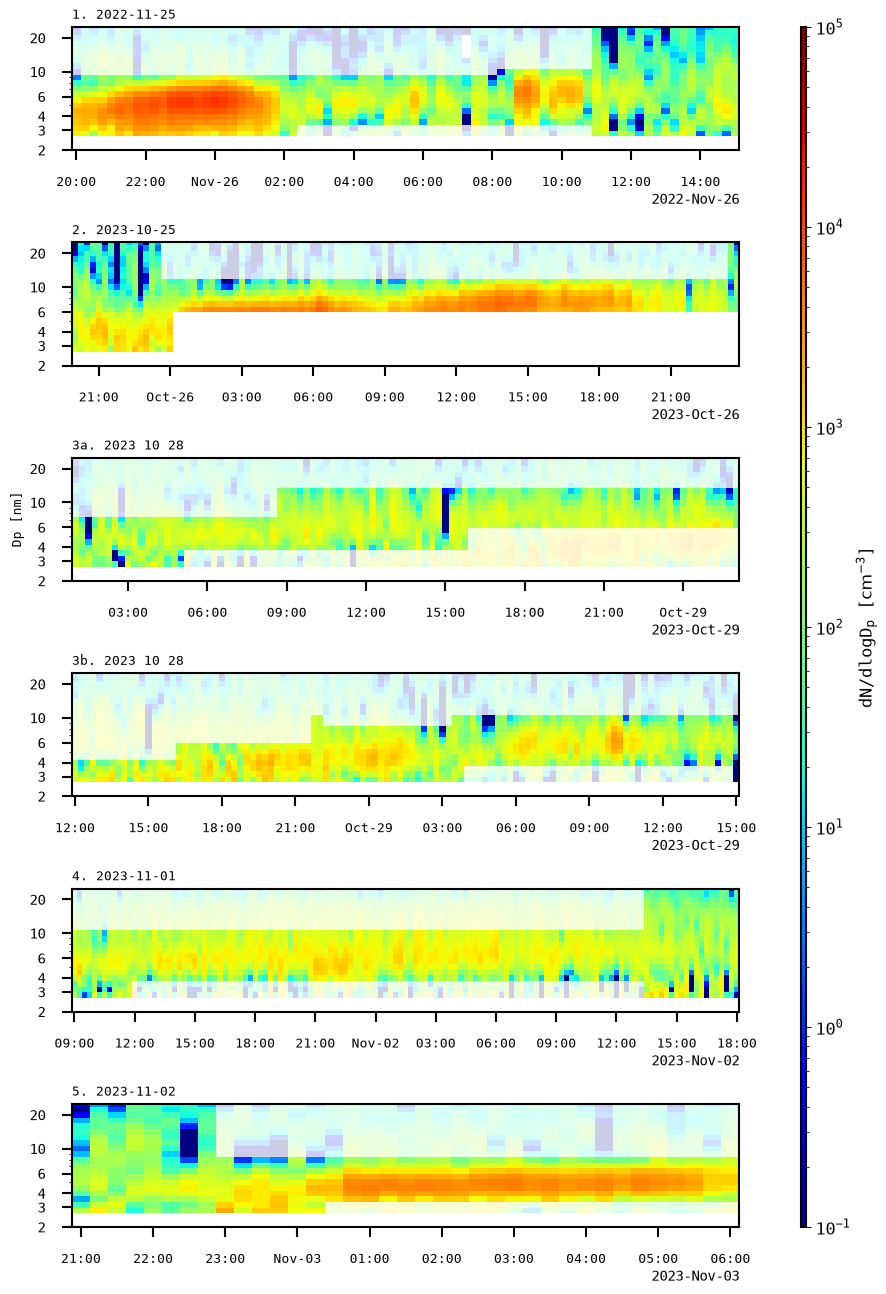

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_S19.jpeg


In [133]:
fig = produce_polar_night_events_figS19(polar_night_dates, events, infile_bounds, fs_label=9, hspace=.75, 
                                  ytick_labels = [2, 3, 4, 6, 10, 20])
output_figure = plots_outpath / 'Figure_S19.jpeg'
save_plot(fig, output_figure)